# Jaguar Re-ID — Linear Baseline

**Architecture** : Flatten → Dense(31, softmax)  
**Improvement over Baseline** : N/A (this IS the baseline)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1775640603.902930 2749955 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775640604.950329 2749955 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775640611.008428 2749955 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
GPU: []


E0000 00:00:1775640612.401054 2749955 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775640612.401821 2750452 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1775640612.476603 2749955 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775640612.476726 2750452 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775640612.494317 2749955 gpu_device.cc:2365] Cannot dlopen some GPU l

In [2]:
MODEL_NAME   = 'linear_baseline'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [4]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "linear_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │     4,666,399 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,666,399 (17.80 MB)

 Trainable params: 4,666,399 (17.80 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (linear_baseline) ===
  lr_0.01: val_acc=0.7098 (best epoch=41)
  lr_0.001: val_acc=0.7177 (best epoch=33)
  lr_0.0001: val_acc=0.7150 (best epoch=27)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.717678,33
1,lr_0.0001,0.715040,27
2,lr_0.01,0.709763,41



Best: lr_0.001 → val_acc=0.7177


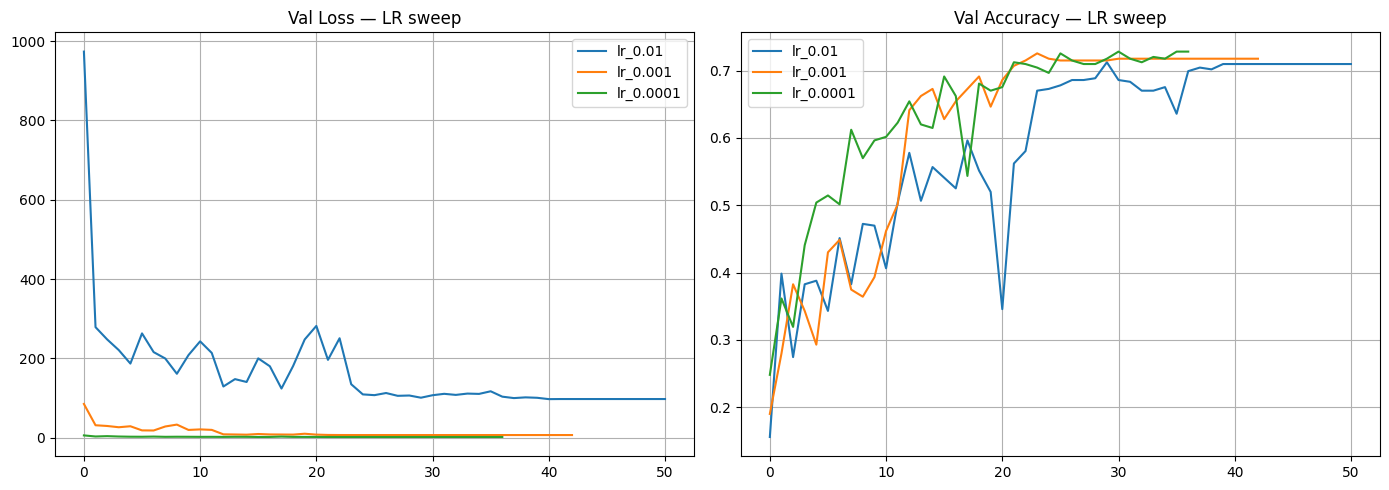

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.0521 - loss: 237.6004 - val_accuracy: 0.1293 - val_loss: 102.3170 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2592 - loss: 48.8902 - val_accuracy: 0.2269 - val_loss: 28.7830 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3760 - loss: 21.2586 - val_accuracy: 0.2982 - val_loss: 23.5877 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4248 - loss: 18.2679 - val_accuracy: 0.3615 - val_loss: 24.5469 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4756 - loss: 18.2702 - val_accuracy: 0.4011 - val_loss: 24.7412 - learning_rate: 0.0010
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5877 - loss: 14.2850 - val_accuracy: 0.4881 - val_loss: 16.4647 - learning_rate: 0.0010
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6478 - loss: 8.1628 

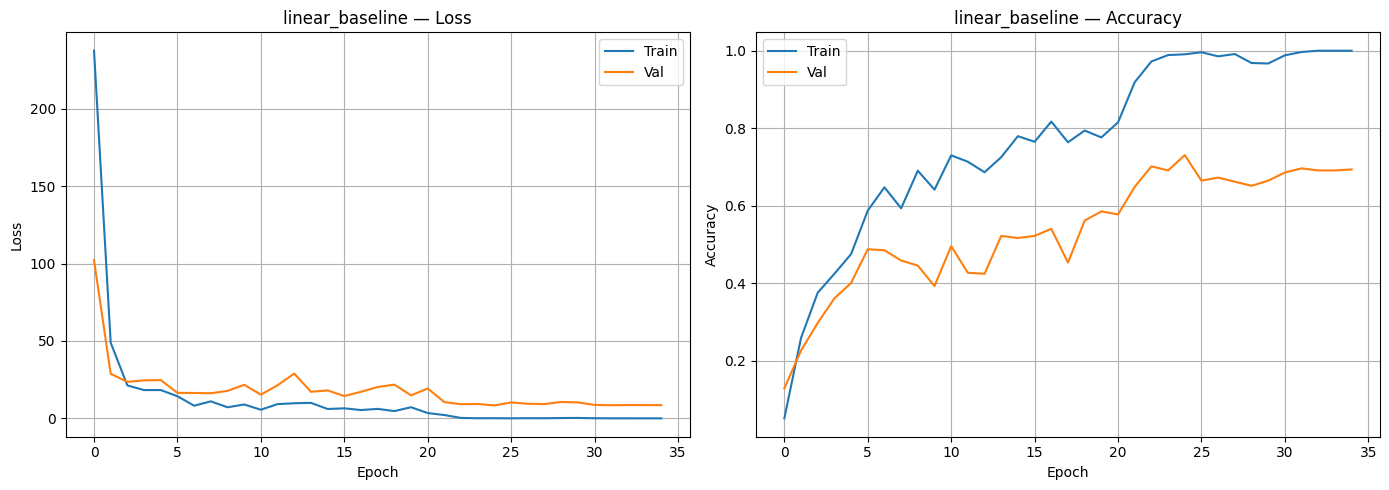

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

linear_baseline (best LR=0.001):
  Train — Loss: 0.0054, Acc: 0.9980
  Val   — Loss: 8.3833, Acc: 0.7309


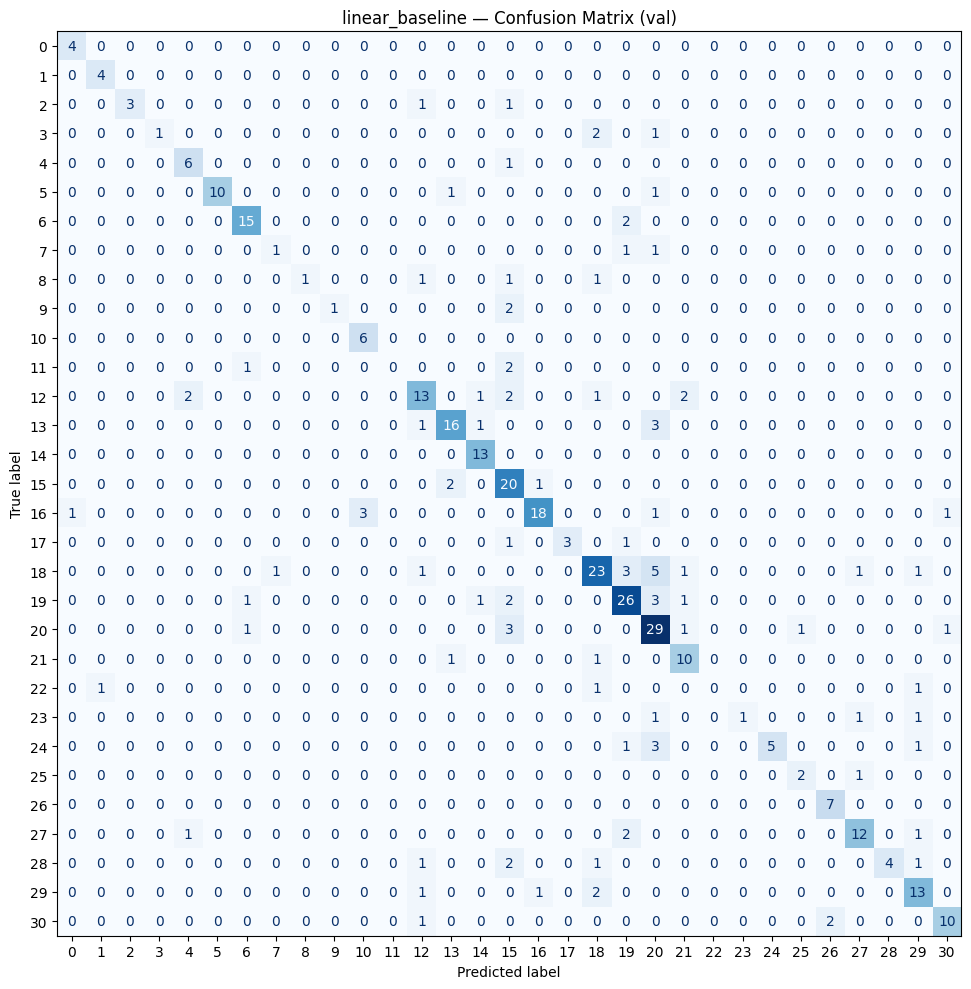

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 33 epochs
Epoch 1/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1013 - loss: 194.3344
Epoch 2/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3145 - loss: 31.9620
Epoch 3/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3937 - loss: 20.6820
Epoch 4/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4053 - loss: 25.6120
Epoch 5/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5683 - loss: 13.9899
Epoch 6/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5821 - loss: 13.2432
Epoch 7/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5588 - loss: 15.0980
Epoch 8/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5847 - loss: 15.6979
Epoch 9/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6311 - loss: 12.0300
Epoch 10/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6343 - loss: 9.7919
Epoch 11/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6649 - loss: 10.07

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7562 - loss: 10.5429
Epoch 20/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7926 - loss: 8.2142 
Epoch 21/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8934 - loss: 2.7660
Epoch 22/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8243 - loss: 4.1433
Epoch 23/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8074 - loss: 5.1712
Epoch 24/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8380 - loss: 5.6283
Epoch 25/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8623 - loss: 4.2814
Epoch 26/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8274 - loss: 5.2012
Epoch 27/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8649 - loss: 3.8480
Epoch 28/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8718 - loss: 2.4452
Epoch 29/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8734 - loss: 2.9520
Epoch 30/33
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 

In [ ]:
inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Embedding shape: (371, 150528)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_linear_baseline.csv


,row_id,similarity
0,0,0.890965
1,1,0.843432
2,2,0.863581
3,3,0.888410
4,4,0.899426


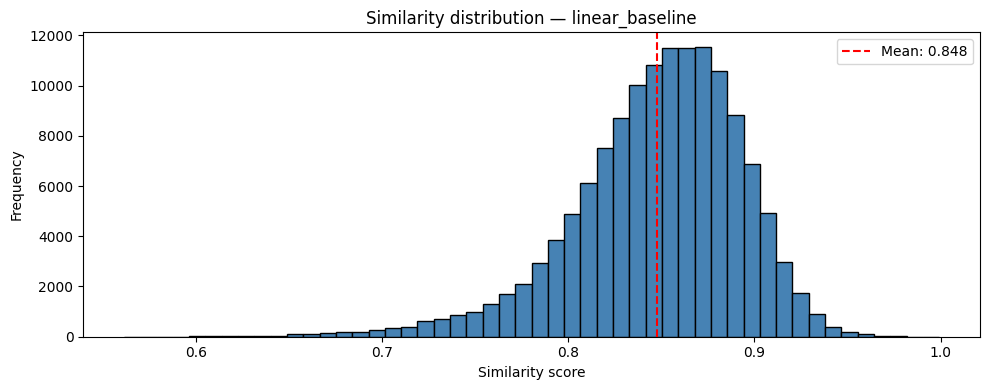

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Metrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.9980 | 0.7309 |
| Loss     | 0.0054 | 8.3833 |
| Overfitting ? | — | Oui (fort) |
| Kaggle Score (public) | — | 0.165 |
| Kaggle Score (private) | — | 0.183 |

### Analyse des hyperparamètres

**Hyperparamètres du modèle :**

- **Structure (Flatten → Dense(31))** : Architecture volontairement minimale — une seule couche linéaire, sans couche cachée. Le Flatten convertit l'image 224×224×3 en un vecteur de 150 528 dimensions, et la Dense(31) apprend une projection linéaire vers les 31 classes. Cela donne 4.6M de paramètres, ce qui est beaucoup pour un modèle aussi simple — mais ces paramètres sont tous dans une seule matrice de poids, sans aucune capacité d'abstraction. L'objectif est d'établir un plancher de performance.

- **Fonction d'activation (softmax en sortie uniquement)** : Pas d'activation intermédiaire puisqu'il n'y a qu'une couche. Le modèle est donc purement linéaire : il ne peut capturer que des frontières de décision linéaires dans l'espace des pixels. Cela limite fondamentalement sa capacité à distinguer des classes qui ne sont pas linéairement séparables dans l'espace pixel.

- **Data augmentation (none)** : Choix justifié par la nature de l'architecture. Un flip horizontal sur des pixels flattened déplace chaque pixel à une position complètement différente dans le vecteur 150k. Sans convolutions, le modèle n'a aucune notion de voisinage spatial — l'augmentation créerait des exemples incohérents plutôt que d'enrichir le dataset. L'augmentation ne sera pertinente qu'avec des architectures qui préservent la structure spatiale (CNN).

**Paramètres d'apprentissage :**

- **Learning rate (sweep : 0.01, 0.001, 0.0001)** : Les 3 LR convergent vers des résultats quasi-identiques (70.9%, 71.8%, 71.5%). Ce plateau montre que le learning rate n'est pas le facteur limitant — le bottleneck est l'architecture elle-même. Quelle que soit la vitesse de convergence, le modèle linéaire atteint le même plafond structurel (~72%).

- **Optimizer (Adam)** : Optimizer par défaut avec momentum adaptatif. Pour un modèle linéaire, un SGD simple fonctionnerait aussi bien, mais Adam converge plus vite sans nécessiter de tuning du momentum. Le choix de l'optimizer n'a pas d'impact significatif sur le résultat final vu le plafond architectural.

- **Batch size (32)** : Valeur par défaut du template. Avec 1516 images → 48 batches/epoch. Pour un modèle linéaire aussi léger (~1s/epoch), modifier le batch size n'aurait pas d'effet notable sur les résultats.

- **EarlyStopping (patience=10) et ReduceLROnPlateau (patience=5, factor=0.5)** : L'EarlyStopping arrête l'entraînement à l'epoch ~35 quand la val_loss stagne. Le ReduceLR intervient à l'epoch 21 (0.001→0.0005) puis 30 (→0.00025), ce qui permet un fine-tuning des poids en fin de training. On observe que train_acc atteint 1.0 dès l'epoch ~33, confirmant la mémorisation totale du dataset.

**Overfitting :**

Le gap train/val est très large : 99.8% vs 73.1% en accuracy, train_loss → 0.005 vs val_loss = 8.38. Le ratio paramètres/données (4.6M params / 1516 images ≈ 3000 params/image) est démesuré, permettant au modèle de mémoriser intégralement les exemples de training sans généraliser. C'est un comportement attendu pour un modèle linéaire surparamétré sur un petit dataset.

### Verdict

- [x] Dead-End : Le sweep montre que les 3 LR convergent vers le même plafond (~72%), l'augmentation n'est pas applicable sur des pixels flattened, et il n'y a pas d'autre hyperparamètre pertinent à tuner sur une seule couche Dense. Le modèle linéaire a extrait tout ce qu'il peut des corrélations pixel-classe. Pour progresser, il faut changer d'architecture.

### Interprétation

La classification fonctionne raisonnablement (73.1%) car le modèle apprend des corrélations directes pixel→classe (certains pixels sont statistiquement discriminants pour certaines classes). Mais le re-ID échoue (Kaggle 0.165/0.183) car la similarité cosinus sur des pixels bruts n'a pas de sens sémantique : deux photos du même jaguar sous des angles différents produisent des vecteurs de pixels très éloignés (la position de chaque pixel change), tandis que deux jaguars différents dans la même pose paraissent proches. Les embeddings sont de dimension 150 528 (les pixels bruts) — bien trop grands et pas assez informatifs. Pour progresser en re-ID, il faut une architecture capable d'extraire des features de haut niveau (patterns de taches, contours, textures) plutôt que de comparer des pixels bruts.